In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import matplotlib.pyplot as plt

from src.env.pricing_env import DynamicPricingEnv

In [2]:
env = DynamicPricingEnv()

state, info = env.reset()

inventory_history = []
days_history = []
revenue_history = []
price_history = []

terminated = False

while not terminated:

    action = env.action_space.sample()

    state, reward, terminated, truncated, info = env.step(action)

    inventory_history.append(state[0])
    days_history.append(state[1])
    revenue_history.append(info["revenue"])
    price_history.append(info["price"])

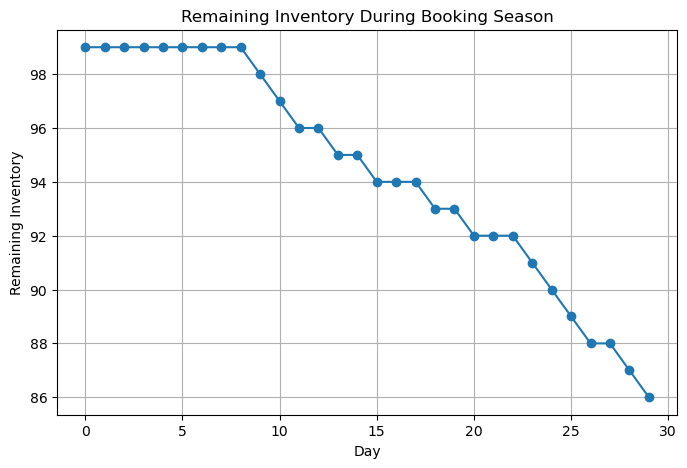

In [3]:
plt.figure(figsize=(8,5))
plt.plot(inventory_history, marker="o")
plt.title("Remaining Inventory During Booking Season")
plt.xlabel("Day")
plt.ylabel("Remaining Inventory")
plt.grid(True)
plt.show()

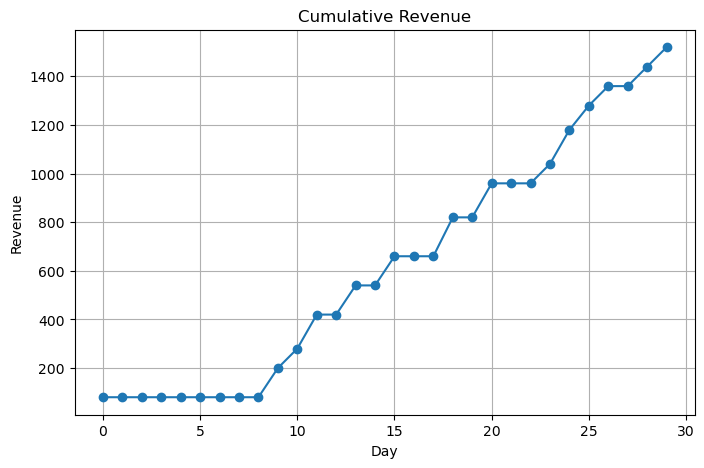

In [4]:
plt.figure(figsize=(8,5))
plt.plot(revenue_history, marker="o")
plt.title("Cumulative Revenue")
plt.xlabel("Day")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

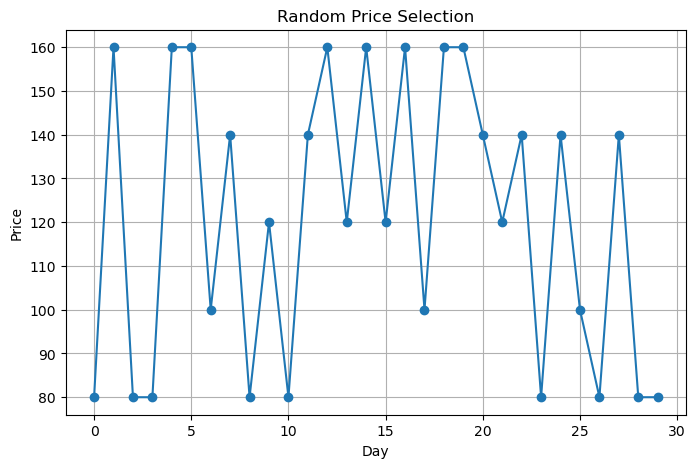

In [5]:
plt.figure(figsize=(8,5))
plt.plot(price_history, marker="o")
plt.title("Random Price Selection")
plt.xlabel("Day")
plt.ylabel("Price")
plt.grid(True)
plt.show()

In [6]:
print("Simulation Summary")
print("-" * 30)
print(f"Final Revenue      : {env.total_revenue}")
print(f"Remaining Inventory: {env.inventory}")
print(f"Days Remaining     : {env.days_left}")

Simulation Summary
------------------------------
Final Revenue      : 1520
Remaining Inventory: 86
Days Remaining     : 0


In [7]:
revenues = []

for _ in range(100):

    env = DynamicPricingEnv()

    state, info = env.reset()

    terminated = False

    while not terminated:

        action = env.action_space.sample()

        state, reward, terminated, truncated, info = env.step(action)

    revenues.append(env.total_revenue)

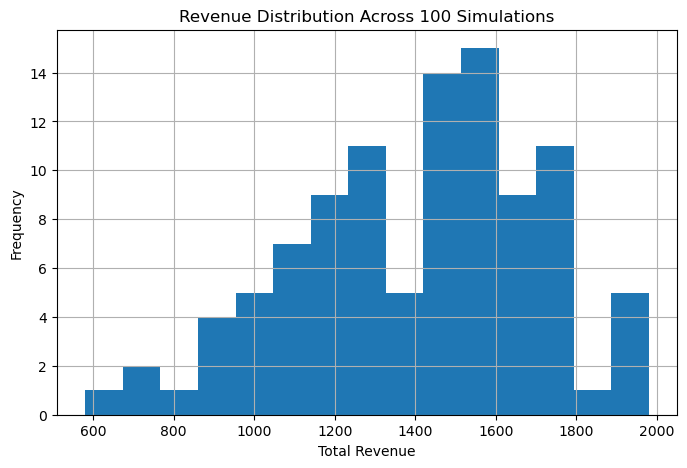

In [8]:
plt.figure(figsize=(8,5))
plt.hist(revenues, bins=15)
plt.title("Revenue Distribution Across 100 Simulations")
plt.xlabel("Total Revenue")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()